In [46]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [47]:
nodes = pd.read_csv(
    "/Users/yimengliu/Documents/Erdos_Institute/mgp/summer26-math-genealogy/data/processed/version2_new_dataset_fitted.csv"
)

In [48]:
nodes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338532 entries, 0 to 338531
Data columns (total 13 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   id                             338532 non-null  int64  
 1   name                           338526 non-null  object 
 2   thesis                         307399 non-null  object 
 3   school                         276167 non-null  object 
 4   country                        322986 non-null  object 
 5   year                           277237 non-null  float64
 6   advisors                       338532 non-null  object 
 7   students                       338532 non-null  object 
 8   subject_code                   280203 non-null  float64
 9   subject_name                   280203 non-null  object 
 10  predicted_subject_code         130825 non-null  float64
 11  subject_prediction_confidence  136040 non-null  float64
 12  subject_prediction_vector     

## 0. Data cleaning

In [49]:
codes=np.sort(nodes.subject_code.dropna().unique())
print(codes)

[ 0.  1.  3.  5.  6.  8. 11. 12. 13. 14. 15. 16. 17. 18. 19. 20. 22. 26.
 28. 30. 31. 32. 33. 34. 35. 37. 39. 40. 41. 42. 43. 44. 45. 46. 47. 49.
 51. 52. 53. 54. 55. 57. 58. 60. 62. 65. 68. 70. 74. 76. 78. 80. 81. 82.
 83. 85. 86. 90. 91. 92. 93. 94. 97.]


In [50]:
#Take data from year between 1900 and 2024
years = np.arange(1900, 2025)

valid_pure = nodes[
    (nodes["subject_code"].notna()) &
    (nodes["subject_code"]<61) &
    (nodes["year"].between(1900, 2026))
].copy()

valid_pure["year"] = valid_pure["year"].astype(int)

codes_pure = np.sort(valid_pure["subject_code"].unique())

counts = pd.crosstab(
    valid_pure["subject_code"],
    valid_pure["year"]
).reindex(index=codes_pure, columns=years, fill_value=0)

year_totals = counts.sum(axis=0).replace(0, np.nan)

share = counts.div(year_totals, axis=1) * 100


In [51]:
counts

year,1900,1901,1902,1903,1904,1905,1906,1907,1908,1909,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
subject_code,,,,,,,,,,,,,,,,,,,,,
0.0,0,1,0,0,0,1,0,0,0,0,...,29,43,32,36,29,27,23,21,14,11
1.0,1,1,0,2,0,1,0,0,1,0,...,7,5,4,4,4,1,5,0,0,2
3.0,0,1,1,1,1,0,0,0,2,0,...,90,84,113,99,94,73,70,72,65,74
5.0,0,0,1,0,0,0,0,0,0,1,...,211,185,197,224,197,169,187,159,151,145
6.0,0,0,0,0,0,0,0,1,0,0,...,18,13,10,17,8,9,10,5,3,10
8.0,0,0,0,0,0,0,0,0,0,0,...,10,9,10,6,10,11,8,5,3,2
11.0,3,2,1,2,0,1,2,2,1,1,...,206,210,194,218,214,181,196,182,166,143
12.0,1,0,0,0,0,0,0,0,0,0,...,9,4,4,2,5,7,4,9,3,7
13.0,0,0,0,0,0,0,0,0,0,0,...,57,39,47,52,46,49,42,41,35,33


In [52]:
counts.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44 entries, 0.0 to 60.0
Columns: 125 entries, 1900 to 2024
dtypes: int64(125)
memory usage: 43.3 KB


In [53]:
#the 9th row is subject=14
codes[9]

np.float64(14.0)

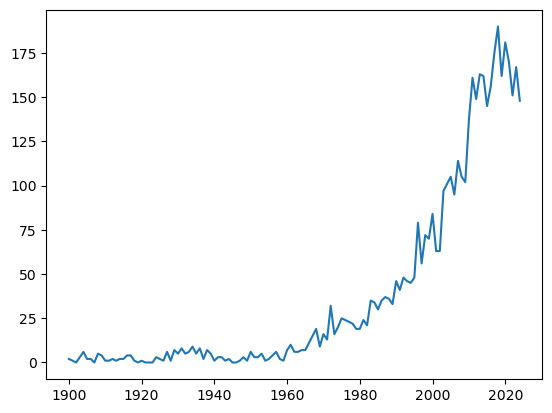

In [54]:
#growth of graduated students in 14=algebraic geometry
plt.plot(counts.iloc[9])

### 1.1 Train-test-split setup

In [55]:
#students in subject=14 train-test-split
counts_train=counts.iloc[9][:-14].copy()
counts_test=counts.iloc[9][-14:].copy()

In [56]:
#precentage of subject=14 train-test-split
share_train=share.iloc[9][:-14].copy()
share_test=share.iloc[9][-14:].copy()

## 1. Simple Expoential smoothing

In [57]:
import statsmodels as sm
from statsmodels.tsa.api import SimpleExpSmoothing

### 1.1 Forcast for number of students in a given subject

In [58]:
simp_exp_smooth_counts = SimpleExpSmoothing(counts_train).fit(smoothing_level=0.5,
                                                                             optimized=False)

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


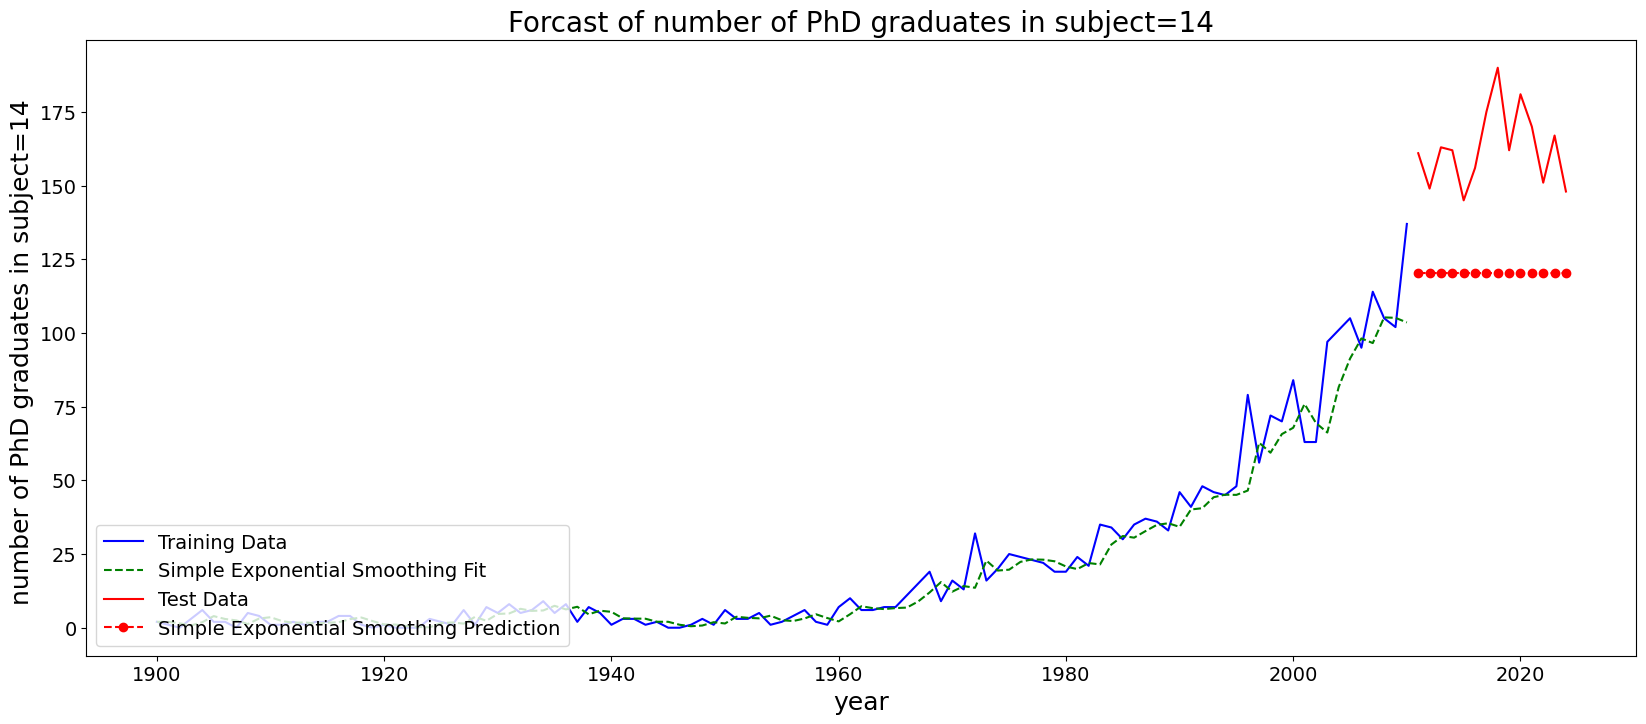

In [59]:
plt.figure(figsize=(20,8))


plt.plot(years[:-14], 
         counts_train,
         'b',
         label="Training Data")


## We can get the fitted values with fittedvalues
plt.plot(years[:-14], 
         simp_exp_smooth_counts.fittedvalues,
         'g--',
         label="Simple Exponential Smoothing Fit")

plt.plot(years[-14:], 
         counts_test[-14:],
         'r',
         label="Test Data")

## We can get the forecast with .forecast(h)
plt.plot(years[-14:], 
         simp_exp_smooth_counts.forecast(14),
         'r--o',
         label="Simple Exponential Smoothing Prediction")

plt.xlabel("year", fontsize=18)
plt.ylabel("number of PhD graduates in subject=14 ", fontsize=18)
plt.title("Forcast of number of PhD graduates in subject=14", fontsize=20)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(fontsize=14, loc=3)

plt.show()

### 1.2 Forcast of precentage

In [63]:
simp_exp_smooth_share= SimpleExpSmoothing(share_train).fit(smoothing_level=0.5,
                                                                             optimized=False)

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


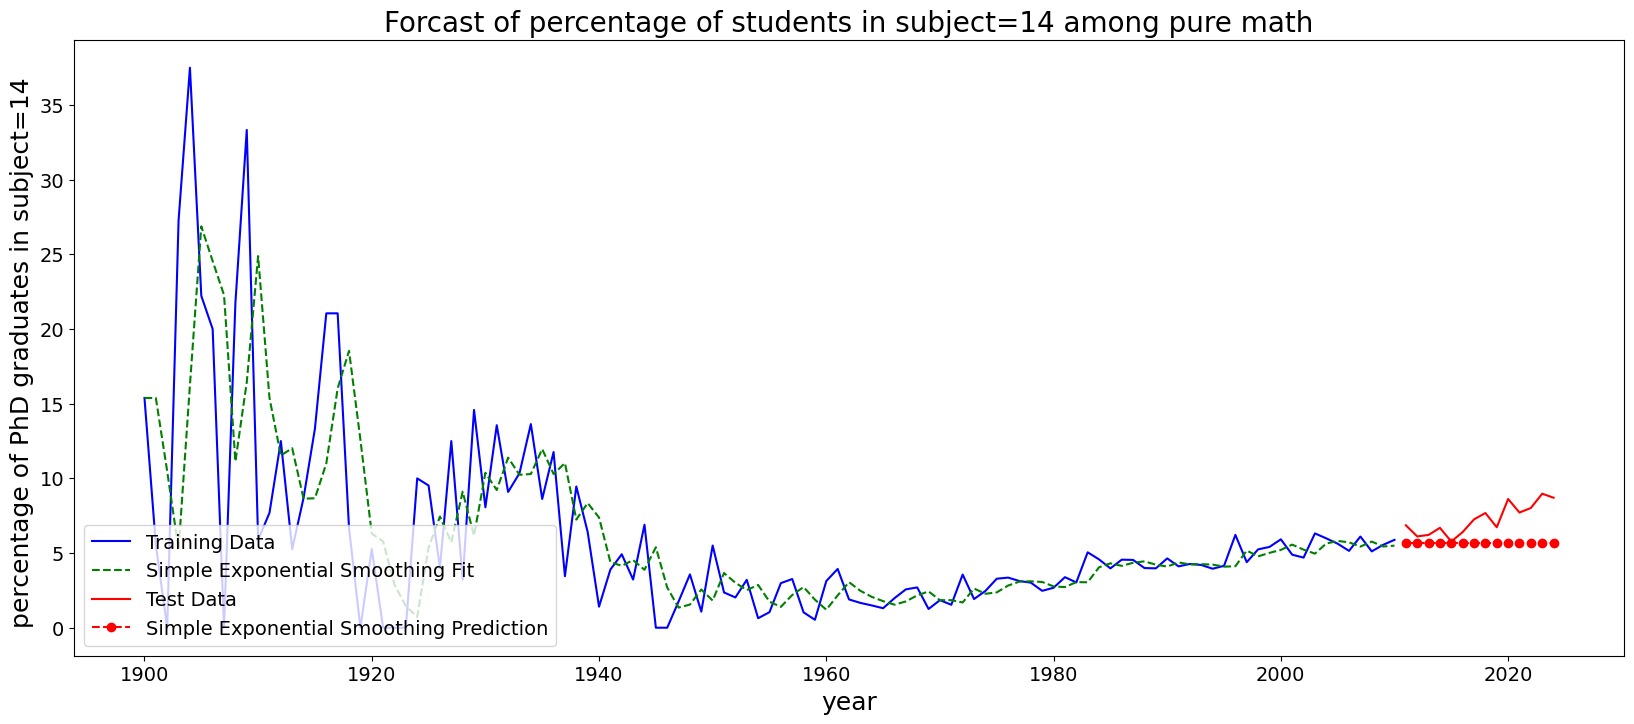

In [64]:
plt.figure(figsize=(20,8))


plt.plot(years[:-14], 
         share_train,
         'b',
         label="Training Data")


## We can get the fitted values with fittedvalues
plt.plot(years[:-14], 
         simp_exp_smooth_share.fittedvalues,
         'g--',
         label="Simple Exponential Smoothing Fit")

plt.plot(years[-14:], 
         share_test[-14:],
         'r',
         label="Test Data")

## We can get the forecast with .forecast(h)
plt.plot(years[-14:], 
         simp_exp_smooth_share.forecast(14),
         'r--o',
         label="Simple Exponential Smoothing Prediction")

plt.xlabel("year", fontsize=18)
plt.ylabel("percentage of PhD graduates in subject=14 ", fontsize=18)
plt.title("Forcast of percentage of students in subject=14 among pure math", fontsize=20)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(fontsize=14, loc=3)

plt.show()

Looks like percentage predict is more unbiased.

## Double exponential smoothing

In [65]:
from statsmodels.tsa.holtwinters import Holt

In [66]:
exp_smooth_counts = Holt(counts_train).fit(smoothing_level=0.8, 
                                                          smoothing_trend=0.8,
                                                          optimized=False)

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


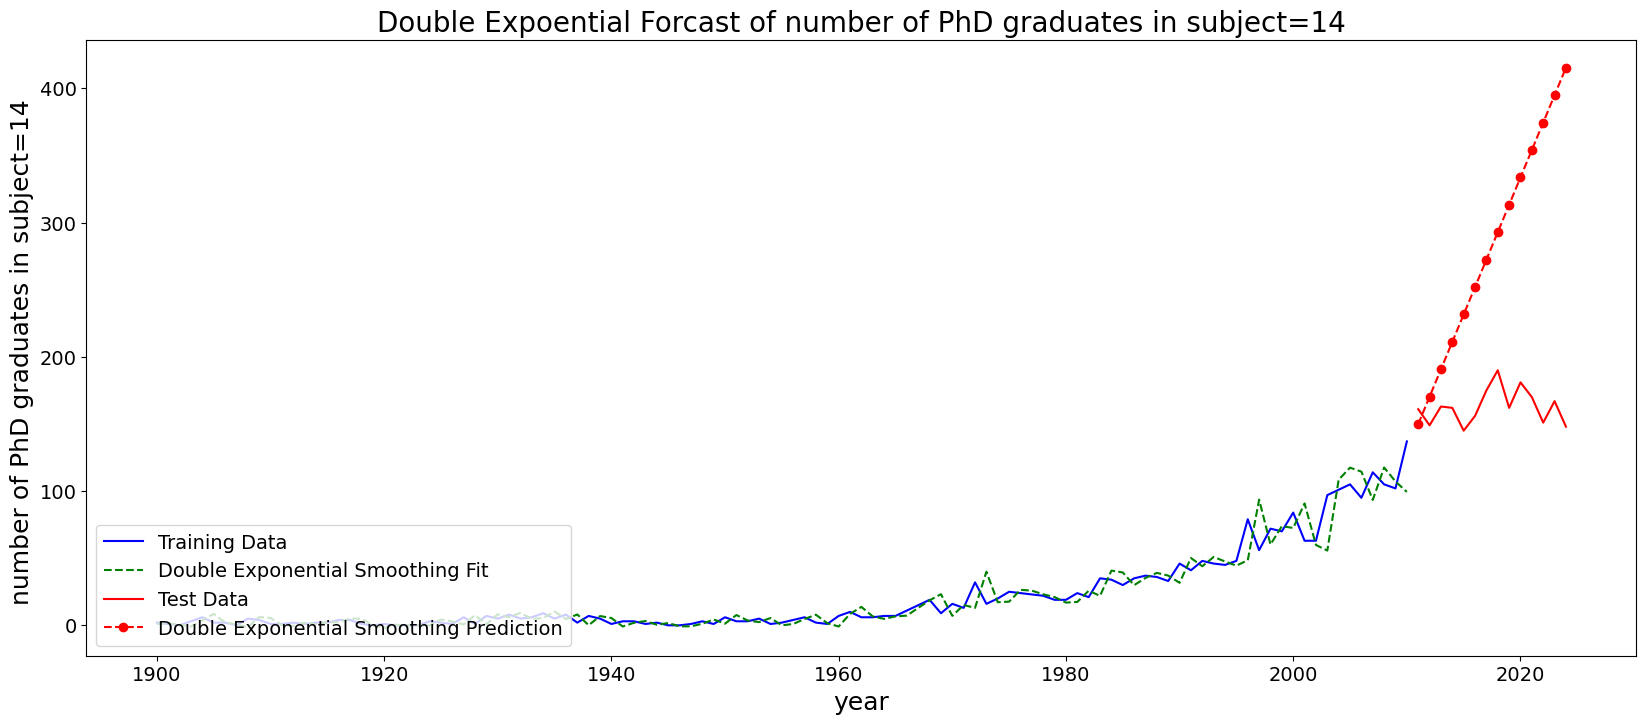

In [67]:
plt.figure(figsize=(20,8))


plt.plot(years[:-14], 
         counts_train,
         'b',
         label="Training Data")


## We can get the fitted values with fittedvalues
plt.plot(years[:-14], 
         exp_smooth_counts.fittedvalues,
         'g--',
         label="Double Exponential Smoothing Fit")

plt.plot(years[-14:], 
         counts_test[-14:],
         'r',
         label="Test Data")

## We can get the forecast with .forecast(h)
plt.plot(years[-14:], 
         exp_smooth_counts.forecast(14),
         'r--o',
         label="Double Exponential Smoothing Prediction")

plt.xlabel("year", fontsize=18)
plt.ylabel("number of PhD graduates in subject=14 ", fontsize=18)
plt.title("Double Expoential Forcast of number of PhD graduates in subject=14", fontsize=20)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(fontsize=14, loc=3)

plt.show()

In [68]:
exp_smooth_share = Holt(share_train).fit(smoothing_level=0.8, 
                                                          smoothing_trend=0.8,
                                                          optimized=False)

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


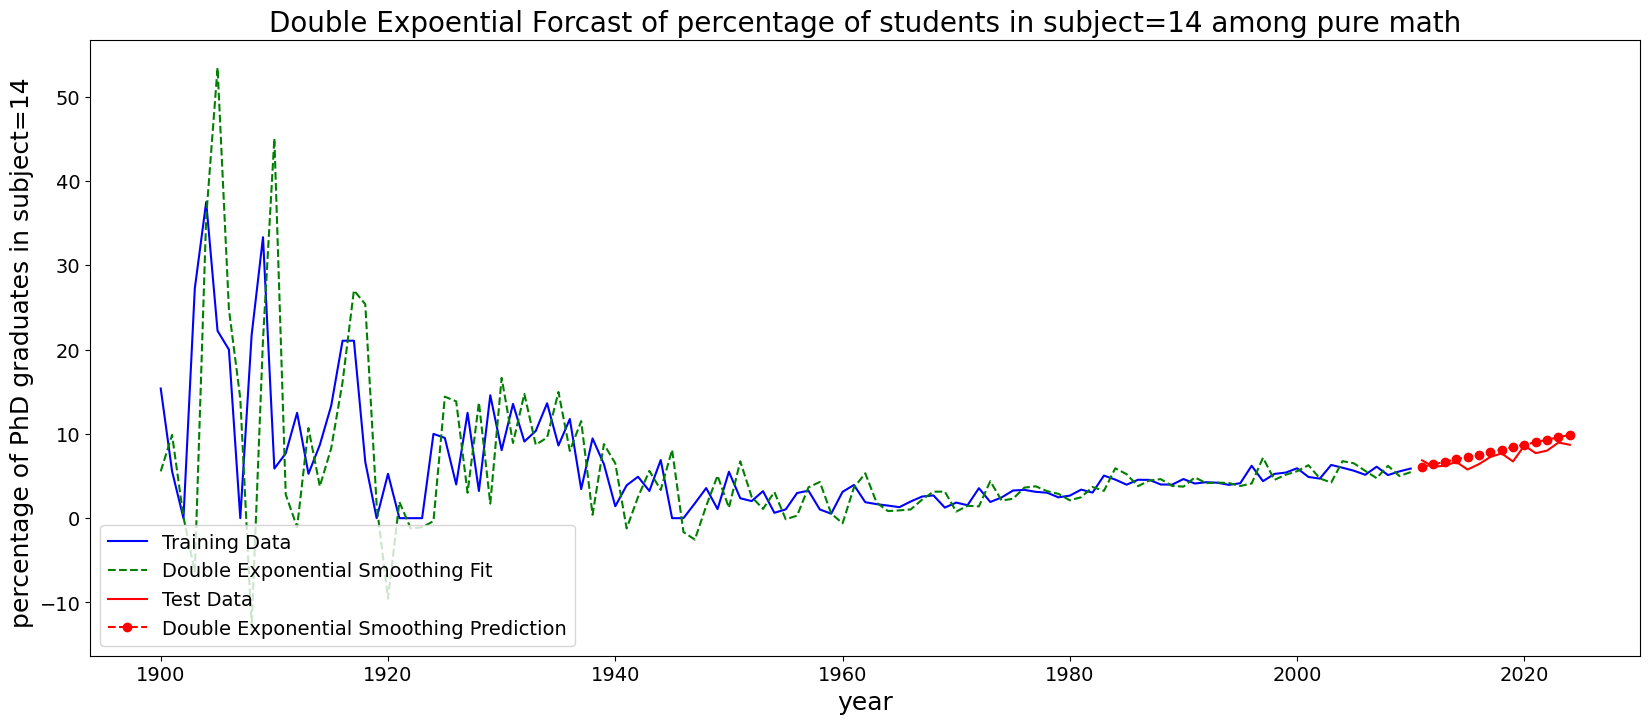

In [69]:
plt.figure(figsize=(20,8))


plt.plot(years[:-14], 
         share_train,
         'b',
         label="Training Data")


## We can get the fitted values with fittedvalues
plt.plot(years[:-14], 
         exp_smooth_share.fittedvalues,
         'g--',
         label="Double Exponential Smoothing Fit")

plt.plot(years[-14:], 
         share_test[-14:],
         'r',
         label="Test Data")

## We can get the forecast with .forecast(h)
plt.plot(years[-14:], 
         exp_smooth_share.forecast(14),
         'r--o',
         label="Double Exponential Smoothing Prediction")

plt.xlabel("year", fontsize=18)
plt.ylabel("percentage of PhD graduates in subject=14 ", fontsize=18)
plt.title("Double Expoential Forcast of percentage of students in subject=14 among pure math", fontsize=20)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.legend(fontsize=14, loc=3)

plt.show()

## 3. Linear trend model (baseline model)

### 3.1 total number of students in `subject` = 14

In [79]:
from sklearn.linear_model import LinearRegression
train_times = years[:-14].reshape(-1, 1)
forecast_times = years[-14:].reshape(-1, 1)

linear_trend_reg = LinearRegression()
linear_trend_reg.fit(train_times,counts_train)
linear_trend_forecast_counts = linear_trend_reg.predict(forecast_times)

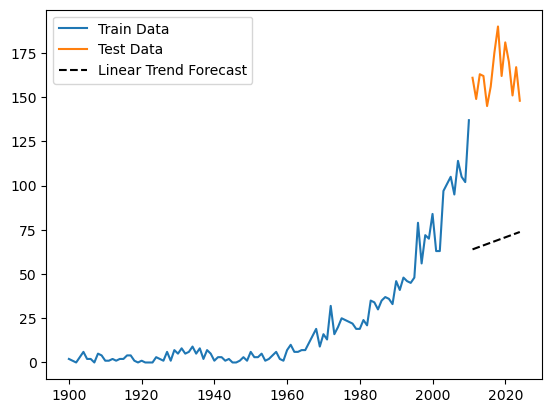

In [80]:
## Plotting the linear trend forecast with the actual data
plt.plot(train_times, counts_train, label = 'Train Data')
plt.plot(forecast_times, counts_test, label = 'Test Data')
plt.plot(forecast_times, linear_trend_forecast_counts, '--k', label = 'Linear Trend Forecast')
plt.legend()
plt.show()

### 3.2 percentage of students in `subject` = 14

In [81]:
from sklearn.linear_model import LinearRegression
train_times = years[:-14].reshape(-1, 1)
forecast_times = years[-14:].reshape(-1, 1)

linear_trend_reg = LinearRegression()
linear_trend_reg.fit(train_times,share_train)
linear_trend_forecast_share = linear_trend_reg.predict(forecast_times)

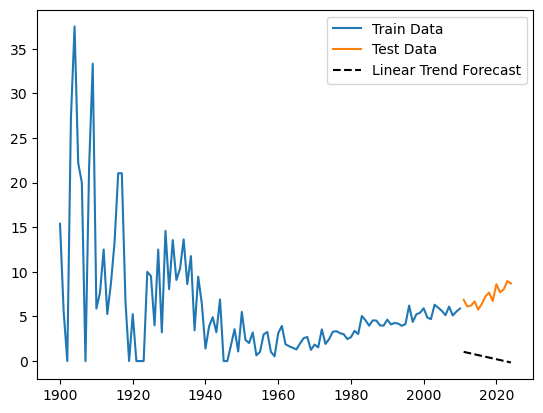

In [82]:
## Plotting the linear trend forecast with the actual data
plt.plot(train_times, share_train, label = 'Train Data')
plt.plot(forecast_times, share_test, label = 'Test Data')
plt.plot(forecast_times, linear_trend_forecast_share, '--k', label = 'Linear Trend Forecast')
plt.legend()
plt.show()

The linear regression model is very off. One may consider polynomial regression, but we won't pursue it here.

## 4. Autocorrelations

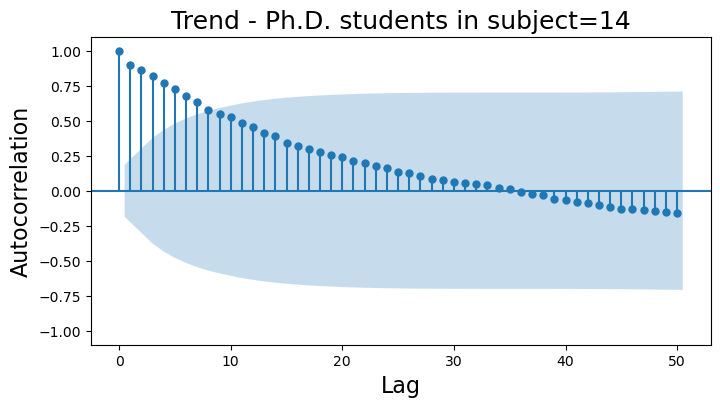

In [102]:
from statsmodels.graphics.tsaplots import plot_acf

# Make sure counts is 1-dimensional

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

plot_acf(
    counts_train,
    lags=min(50, len(counts_train) - 1),
    ax=ax
)

ax.set_title('Trend - Ph.D. students in subject=14', fontsize=18)
ax.set_ylabel("Autocorrelation", fontsize=16)
ax.set_xlabel("Lag", fontsize=16)
ax.set_ylim(-1.1, 1.1)

plt.show()

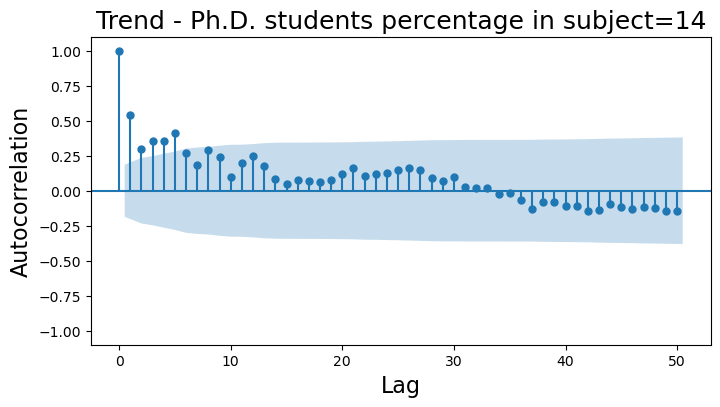

In [103]:
# We do the same thing for percentage

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

plot_acf(
    share_train,
    lags=min(50, len(share_train) - 1),
    ax=ax
)

ax.set_title('Trend - Ph.D. students percentage in subject=14', fontsize=18)
ax.set_ylabel("Autocorrelation", fontsize=16)
ax.set_xlabel("Lag", fontsize=16)
ax.set_ylim(-1.1, 1.1)

plt.show()

## 5. Arima

In [ ]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 591.9/591.9 kB 11.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 13.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pmdarima]1/2 [pmdarima]
Note: you may need to restart the kernel to use updated packages.


In [85]:
import pmdarima as pm

In [117]:
model_002_counts = pm.ARIMA(
    order=(0, 0, 2),
    with_intercept=False
).fit(counts_train)

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [124]:
model_002_share = pm.ARIMA(
    order=(0, 0, 2),
    with_intercept=False
).fit(share_train)

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [125]:
pred_002_counts = model_002_counts.predict(
    n_periods=len(counts_test)
)

pred_002_share = model_002_share.predict(
    n_periods=len(share_test)
)

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_pred

In [120]:
model_002_counts.predict(14)

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


111    133.820265
112     98.862278
113      0.000000
114      0.000000
115      0.000000
116      0.000000
117      0.000000
118      0.000000
119      0.000000
120      0.000000
121      0.000000
122      0.000000
123      0.000000
124      0.000000
dtype: float64

## 6. Auto arima: auto search other parameters

In [92]:
from pmdarima import auto_arima

In [107]:
model_counts=auto_arima(counts_train, trace = True)
pred_counts = model_counts.predict(n_periods=len(counts_test))

Performing stepwise search to minimize aic
 ARIMA(2,2,2)(0,0,0)[0]             : AIC=725.659, Time=0.62 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=871.342, Time=0.01 sec
 ARIMA(1,2,0)(0,0,0)[0]             : AIC=817.224, Time=0.01 sec
 ARIMA(0,2,1)(0,0,0)[0]             : AIC=772.307, Time=0.02 sec
 ARIMA(1,2,2)(0,0,0)[0]             : AIC=723.870, Time=0.04 sec
 ARIMA(0,2,2)(0,0,0)[0]             : AIC=721.871, Time=0.08 sec
 ARIMA(0,2,3)(0,0,0)[0]             : AIC=723.870, Time=0.09 sec
 ARIMA(1,2,1)(0,0,0)[0]             : AIC=749.914, Time=0.06 sec
 ARIMA(1,2,3)(0,0,0)[0]             : AIC=725.834, Time=0.16 sec
 ARIMA(0,2,2)(0,0,0)[0] intercept   : AIC=721.938, Time=0.12 sec

Best model:  ARIMA(0,2,2)(0,0,0)[0]          
Total fit time: 1.211 seconds


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [108]:
print(model_counts.order)          # selected (p, d, q)
print(model_counts.seasonal_order) # selected (P, D, Q, s)
print(model_counts.params())       # fitted coefficients / parameters
print(model_counts.summary())      # full model summary

(0, 2, 2)
(0, 0, 0, 0)
ma.L1     -1.765250
ma.L2      0.826949
sigma2    39.794192
dtype: float64
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  111
Model:               SARIMAX(0, 2, 2)   Log Likelihood                -357.935
Date:                Thu, 02 Jul 2026   AIC                            721.871
Time:                        11:50:18   BIC                            729.945
Sample:                             0   HQIC                           725.145
                                - 111                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -1.7653      0.053    -33.186      0.000      -1.870      -1.661
ma.L2          0.8269      0.049 

In [ ]:
auto_arima

So for the number of students gradated from `subject =14` per year, `auto_arima` has selected a model with an $\operatorname{MA}(2)$ component.  In other words, the model is:

$$
\Delta^2y_{t} = \epsilon_t −1.7653 \epsilon_{t-1} +0.8269\epsilon_{t-2}
$$
with 
$$
\epsilon_t \sim N(0,39.79)
$$

where $\epsilon_t$ are Gaussian white noise.

The order  $(p,d,q)=(0,2,2)$ means $p=0$: no AR part

$d=2$: the series was differenced twice before fitting

$q=2$: there are two moving-average terms
seasonal part is effectively absent

We do the same search for percentage

In [109]:
model_share=auto_arima(share_train, trace = True)
pred_share = model_share.predict(n_periods=len(share_test))

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=681.992, Time=0.13 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=720.070, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=716.200, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=692.792, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=718.091, Time=0.01 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=680.872, Time=0.12 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=683.204, Time=0.07 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=687.415, Time=0.06 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=681.629, Time=0.18 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=682.641, Time=0.11 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=683.921, Time=0.07 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=683.554, Time=0.26 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=679.975, Time=0.06 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=682.518, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=686.6

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [110]:
print(model_share.order)          # selected (p, d, q)
print(model_share.seasonal_order) # selected (P, D, Q, s)
print(model_share.params())       # fitted coefficients / parameters
print(model_share.summary())      # full model summary

(1, 1, 2)
(0, 0, 0, 0)
ar.L1     -0.597700
ma.L1      0.078507
ma.L2     -0.772604
sigma2    25.955798
dtype: float64
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  111
Model:               SARIMAX(1, 1, 2)   Log Likelihood                -335.987
Date:                Thu, 02 Jul 2026   AIC                            679.975
Time:                        11:56:25   BIC                            690.776
Sample:                             0   HQIC                           684.356
                                - 111                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5977      0.079     -7.605      0.000      -0.752      -0.444
ma.L1        

For the percentage of students gradated from `subject =14` per year, `auto_arima` has selected a model with an $AR(1)$ component and $\operatorname{MA}(2)$ component.  In other words, the model is:

$$
\Delta y_{t} = -0.597700\Delta y_{t-1}+\epsilon_t +0.078507 \epsilon_{t-1} -0.772604\epsilon_{t-2}
$$
with 
$$
\epsilon_t \sim N(0,25.955798)
$$

where $\epsilon_t$ are Gaussian white noise.



## 5. comparison of the different models

In [71]:
from sklearn.metrics import mean_squared_error as mse

In [128]:
count_mses = {
    "Simple exponential smoothing":
        mse(counts_test, simp_exp_smooth_counts.forecast(len(counts_test))),

    "Double exponential smoothing":
        mse(counts_test, exp_smooth_counts.forecast(len(counts_test))),

    "Linear trend":
        mse(counts_test, linear_trend_forecast_counts),

    "ARIMA(0,0,2)":
        mse(counts_test, pred_002_counts),

    "Auto ARIMA":
        mse(counts_test, pred_counts)
}

count_mses

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_pred

{'Simple exponential smoothing': 1969.8483222272296,
 'Double exponential smoothing': 21007.141172021376,
 'Linear trend': 8989.214011776307,
 'ARIMA(0,0,2)': 23475.037801527935,
 'Auto ARIMA': 558.5527601899286}

#### So auto_aroma did the best.

For percentage

In [129]:
share_mses = {
    "Simple exponential smoothing":
        mse(share_test, simp_exp_smooth_share.forecast(len(share_test))),

    "Double exponential smoothing":
        mse(share_test, exp_smooth_share.forecast(len(share_test))),

    "Linear trend":
        mse(share_test, linear_trend_forecast_share),

    "ARIMA(0,0,2)":
        mse(share_test, pred_002_share),

    "Auto ARIMA":
        mse(share_test, pred_share)
}

share_mses

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_pred

{'Simple exponential smoothing': 3.485970094230867,
 'Double exponential smoothing': 0.9338377065956068,
 'Linear trend': 48.391990318513116,
 'ARIMA(0,0,2)': 50.98532006157991,
 'Auto ARIMA': 4.251230075111821}

#### So the Double Exp smooth did the best.